# 07. Nested Walk-forward HPO — CatBoost vs MLP

## 목적

06에서 다음을 확인했습니다.

- 현재 강한 tabular baseline은 CatBoost
- Baseline MLP도 경쟁력 있음
- 고득점자 과소예측은 MLP만의 문제가 아니라 여러 회귀 모델에서 반복됨

07에서는 **CatBoost와 MLP를 각각 제대로 튜닝**합니다.

단, 중요한 원칙이 있습니다.

> Outer Validation을 Optuna 목적함수에 직접 사용하지 않습니다.

그렇게 하면 Outer Validation 자체에 하이퍼파라미터가 과적합될 수 있기 때문입니다.

---

## Nested Walk-forward 구조

각 Outer Fold마다:

```text
과거 데이터
    ↓
Outer Train
    ├─ Inner Walk-forward Fold 1
    ├─ Inner Walk-forward Fold 2
    └─ Inner Walk-forward Fold 3
            ↓
        Optuna HPO
            ↓
    Best Hyperparameters
            ↓
Outer Train 내부 마지막 시즌
→ 최종 boosting rounds / epoch 결정
            ↓
Outer Train 전체 재학습
            ↓
Outer Validation 단 1회 평가
```

### 비교 대상

- Tuned CatBoost
- Tuned MLP

### 이번 Notebook에서 **고정하는 것**

- Feature set: Exp9Cb
- Target: matched_next=True 조건부 `next_goals`
- MLP loss: MSE
- Primary metric: MAE
- Test: 계속 잠금

### 이번 Notebook에서 **튜닝하는 것**

CatBoost:
- depth
- learning_rate
- l2_leaf_reg
- random_strength
- bagging_temperature

MLP:
- hidden architecture
- dropout
- learning_rate
- weight_decay
- batch_size

### 이번 Notebook에서 일부러 하지 않는 것

- Weighted MSE
- SmoothL1
- Player / Team Embedding 재검증
- Feature set 재선택
- Test 평가

이들은 모델 구조/학습 설정이 정해진 뒤 별도 실험으로 다룹니다.

## 0. 실행 전 설정

Nested HPO는 일반 baseline 비교보다 학습 횟수가 많습니다.

먼저 아래 설정으로 전체 흐름을 검증하고, 최종 탐색에서는 trial 수를 늘릴 수 있습니다.

권장 흐름:

1. `N_TRIALS_CATBOOST = 15`, `N_TRIALS_MLP = 15`로 전체 실행 확인
2. 코드/데이터 문제가 없으면 필요 시 30~50 trials로 확대
3. Outer Fold 수는 줄이지 않음
4. Test는 계속 사용하지 않음

**Trial 수를 늘리는 것은 탐색 강도를 높이는 것이지, 평가 프로토콜을 바꾸는 것이 아닙니다.**

In [1]:
from pathlib import Path
import random
import time
import warnings
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# HPO 강도
N_TRIALS_CATBOOST = 15
N_TRIALS_MLP = 15

# 각 Outer Train 안에서 최근 몇 시즌을 Inner Validation으로 쓸지
N_INNER_FOLDS = 3

# Early stopping
CATBOOST_MAX_ITER = 2000
CATBOOST_PATIENCE = 50

MLP_MAX_EPOCHS = 120
MLP_PATIENCE = 12

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

reset_seed()

print("Device:", DEVICE)
print("CatBoost trials:", N_TRIALS_CATBOOST)
print("MLP trials:", N_TRIALS_MLP)
print("Inner folds:", N_INNER_FOLDS)

Device: cpu
CatBoost trials: 15
MLP trials: 15
Inner folds: 3


## 1. 라이브러리 확인

필요 패키지:

- `optuna`
- `catboost`

설치되지 않았다면 아래 출력의 명령으로 설치 후 커널을 재시작합니다.

In [2]:
HAS_OPTUNA = True
HAS_CATBOOST = True

try:
    import optuna
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner
    print("optuna:", optuna.__version__)
except ImportError:
    HAS_OPTUNA = False
    print("[MISSING] optuna")

try:
    import catboost
    from catboost import CatBoostRegressor
    print("catboost:", catboost.__version__)
except ImportError:
    HAS_CATBOOST = False
    print("[MISSING] catboost")

missing = []
if not HAS_OPTUNA:
    missing.append("optuna")
if not HAS_CATBOOST:
    missing.append("catboost")

if missing:
    print("\n설치 예시:")
    print("pip install " + " ".join(missing))
    print("설치 후 Jupyter kernel을 재시작하세요.")

optuna: 4.9.0
catboost: 1.2.10


## 2. 데이터 파일 탐색

07은 05/06 Notebook 메모리에 의존하지 않고 새 커널에서 단독 실행 가능하도록 구성합니다.

필요 파일:

- long_basic Train
- long_basic Validation
- team season stats
- team alias map

**Test는 로드하지 않습니다.**

In [3]:
MANUAL_TRAIN_PATH = None
MANUAL_VALIDATION_PATH = None
MANUAL_TEAM_STATS_PATH = None
MANUAL_ALIAS_PATH = None

SEARCH_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]
SEARCH_ROOTS = list(dict.fromkeys(p.resolve() for p in SEARCH_ROOTS if p.exists()))

LONG_BASIC_REQUIRED = {
    "player", "team", "league", "season", "target_season",
    "position_group", "age", "matched_next", "starts", "minutes",
    "goals", "assists", "non_penalty_goals", "penalty_goals",
    "penalty_attempts", "goals_per90", "assists_per90",
    "goal_contrib_per90", "next_goals"
}
ADVANCED_FORBIDDEN = {"xg", "xag", "shots", "progressive_carries"}

def read_header(path):
    try:
        return set(pd.read_csv(path, nrows=0).columns)
    except Exception:
        return set()

def find_csv_by_schema(kind):
    candidates = []

    for root in SEARCH_ROOTS:
        try:
            for path in root.rglob("*.csv"):
                if any(part.startswith(".") for part in path.parts):
                    continue

                cols = read_header(path)

                if kind in {"train", "validation"}:
                    if not LONG_BASIC_REQUIRED.issubset(cols):
                        continue
                    if ADVANCED_FORBIDDEN.intersection(cols):
                        continue

                    name = path.name.lower()
                    sample = pd.read_csv(path, usecols=["season"], nrows=100)
                    seasons = set(sample["season"].astype(str))

                    if kind == "train":
                        score = int("train" in name) + int("2000-2001" in seasons)
                    else:
                        score = (
                            int("validation" in name or "val" in name)
                            + int("2023-2024" in seasons)
                        )

                    candidates.append((score, path))

                elif kind == "team_stats":
                    needed = {
                        "league", "season", "team_name",
                        "team_rank_pct",
                        "team_points_per_game",
                        "team_goal_diff_per_game",
                    }
                    if needed.issubset(cols):
                        candidates.append(
                            (2 if "team_season_stats" in path.name.lower() else 1, path)
                        )

                elif kind == "alias":
                    needed = {"player_data_team", "standings_team"}
                    if needed.issubset(cols):
                        candidates.append(
                            (2 if "alias" in path.name.lower() else 1, path)
                        )
        except (PermissionError, OSError):
            continue

    if not candidates:
        return None

    candidates.sort(key=lambda x: (x[0], -len(str(x[1]))), reverse=True)
    return candidates[0][1]

def resolve_path(manual_path, kind):
    if manual_path is not None:
        path = Path(manual_path)
        if not path.exists():
            raise FileNotFoundError(f"지정한 경로가 없습니다: {path}")
        return path

    path = find_csv_by_schema(kind)
    if path is None:
        raise FileNotFoundError(
            f"{kind} 파일을 자동으로 찾지 못했습니다. MANUAL_*_PATH에 직접 지정하세요."
        )
    return path

TRAIN_PATH = resolve_path(MANUAL_TRAIN_PATH, "train")
VALIDATION_PATH = resolve_path(MANUAL_VALIDATION_PATH, "validation")
TEAM_STATS_PATH = resolve_path(MANUAL_TEAM_STATS_PATH, "team_stats")
ALIAS_PATH = resolve_path(MANUAL_ALIAS_PATH, "alias")

print("TRAIN      :", TRAIN_PATH)
print("VALIDATION :", VALIDATION_PATH)
print("TEAM STATS :", TEAM_STATS_PATH)
print("ALIAS      :", ALIAS_PATH)

TRAIN      : D:\dev\03_PersonalProjects\next_season_goal_prediction\data\long_basic\train.csv
VALIDATION : D:\dev\03_PersonalProjects\next_season_goal_prediction\data\long_basic\validation.csv
TEAM STATS : D:\dev\03_PersonalProjects\next_season_goal_prediction\data\team_season_stats_2000_2024.csv
ALIAS      : D:\dev\03_PersonalProjects\next_season_goal_prediction\data\team_name_alias_map.csv


In [4]:
train_raw = pd.read_csv(TRAIN_PATH)
validation_raw = pd.read_csv(VALIDATION_PATH)
team_stats_raw = pd.read_csv(TEAM_STATS_PATH)
team_alias_raw = pd.read_csv(ALIAS_PATH)

for df in [train_raw, validation_raw, team_stats_raw, team_alias_raw]:
    drop_cols = [
        c for c in df.columns
        if c.lower().startswith("unnamed") or c == "index"
    ]
    if drop_cols:
        df.drop(columns=drop_cols, inplace=True)

print("Train shape      :", train_raw.shape)
print("Validation shape :", validation_raw.shape)
print("Train seasons    :", train_raw["season"].min(), "~", train_raw["season"].max())
print("Validation season:", validation_raw["season"].unique())
print("Advanced columns present:", sorted(ADVANCED_FORBIDDEN.intersection(train_raw.columns)))

Train shape      : (22430, 22)
Validation shape : (923, 22)
Train seasons    : 2000-2001 ~ 2022-2023
Validation season: <StringArray>
['2023-2024']
Length: 1, dtype: str
Advanced columns present: []


## 3. Test Lock

In [5]:
LOCKED_TEST_INPUT_SEASON = "2024-2025"
LOCKED_TEST_TARGET_SEASON = "2025-2026"

assert LOCKED_TEST_INPUT_SEASON not in set(train_raw["season"].astype(str))
assert LOCKED_TEST_INPUT_SEASON not in set(validation_raw["season"].astype(str))

print("Locked Test:", LOCKED_TEST_INPUT_SEASON, "→", LOCKED_TEST_TARGET_SEASON)
print("Test CSV is NOT loaded.")

Locked Test: 2024-2025 → 2025-2026
Test CSV is NOT loaded.


## 4. Exp9Cb Feature 재생성

06과 완전히 같은 정보만 사용합니다.

### Numeric 17개

기본 11개:
- age
- starts
- minutes
- goals
- assists
- non_penalty_goals
- penalty_goals
- penalty_attempts
- goals_per90
- assists_per90
- goal_contrib_per90

과거 scoring trend 3개:
- goals_3yr_mean
- goals_per90_3yr_mean
- goals_3yr_max

팀 종합 성적 3개:
- team_rank_pct
- team_points_per_game
- team_goal_diff_per_game

### Categorical
- league
- position_group

In [6]:
dev_raw = pd.concat(
    [train_raw, validation_raw],
    ignore_index=True
).copy()

dev_raw["season_start"] = dev_raw["season"].astype(str).str[:4].astype(int)
dev_raw = dev_raw.sort_values(["player", "season_start"]).reset_index(drop=True)

player_group = dev_raw.groupby("player", sort=False)

dev_raw["goals_3yr_mean"] = player_group["goals"].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
)
dev_raw["goals_per90_3yr_mean"] = player_group["goals_per90"].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
)
dev_raw["goals_3yr_max"] = player_group["goals"].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).max()
)

HISTORICAL_COLS = [
    "goals_3yr_mean",
    "goals_per90_3yr_mean",
    "goals_3yr_max",
]

dev_raw[HISTORICAL_COLS] = dev_raw[HISTORICAL_COLS].fillna(0.0)

print("Development rows:", len(dev_raw))
print("Season range:", dev_raw["season"].min(), "~", dev_raw["season"].max())

Development rows: 23353
Season range: 2000-2001 ~ 2023-2024


In [7]:
team_name_map = dict(zip(
    team_alias_raw["player_data_team"],
    team_alias_raw["standings_team"]
))

team_name_map.update({
    "Gladbach": "M'gladbach",
    "Luton Town": "Luton",
})

dev = dev_raw.copy()
dev["team_name"] = dev["team"].replace(team_name_map)

team_stats = team_stats_raw.copy()

if "position" in team_stats.columns and "team_rank" not in team_stats.columns:
    team_stats = team_stats.rename(columns={"position": "team_rank"})

TEAM_NUMERIC = [
    "team_rank_pct",
    "team_points_per_game",
    "team_goal_diff_per_game",
]

team_keep_cols = ["league", "season", "team_name"] + TEAM_NUMERIC

team_stats = team_stats[team_keep_cols].drop_duplicates(
    subset=["league", "season", "team_name"]
)

dev = dev.merge(
    team_stats,
    on=["league", "season", "team_name"],
    how="left",
    validate="many_to_one",
)

match_ratio = dev[TEAM_NUMERIC].notna().all(axis=1).mean()
print(f"Team feature match ratio: {match_ratio:.4%}")

if match_ratio <= 0.99:
    unmatched = dev.loc[
        dev[TEAM_NUMERIC].isna().any(axis=1),
        ["league", "season", "team", "team_name"]
    ].drop_duplicates()
    display(unmatched.head(30))

assert match_ratio > 0.99, "팀 성적 매칭률이 99% 이하입니다."

Team feature match ratio: 100.0000%


In [8]:
model_df = dev[dev["matched_next"] == True].copy()
model_df = model_df.sort_values(["season_start", "player"]).reset_index(drop=True)

BASE_NUMERIC = [
    "age",
    "starts",
    "minutes",
    "goals",
    "assists",
    "non_penalty_goals",
    "penalty_goals",
    "penalty_attempts",
    "goals_per90",
    "assists_per90",
    "goal_contrib_per90",
]

FINAL_NUMERIC = BASE_NUMERIC + HISTORICAL_COLS + TEAM_NUMERIC
FINAL_CATEGORICAL = ["league", "position_group"]
FEATURE_COLS = FINAL_NUMERIC + FINAL_CATEGORICAL
TARGET = "next_goals"

print("Conditional rows:", len(model_df))
print("Numeric count:", len(FINAL_NUMERIC))
print("Categorical:", FINAL_CATEGORICAL)

Conditional rows: 19403
Numeric count: 17
Categorical: ['league', 'position_group']


## 5. Outer Walk-forward Fold

05/06과 동일하게 유지합니다.

In [9]:
OUTER_VAL_SEASONS = [
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]

outer_fold_plan = []

for fold_id, outer_val_season in enumerate(OUTER_VAL_SEASONS, start=1):
    outer_val_start = int(outer_val_season[:4])

    outer_train_df = model_df[
        model_df["season_start"] < outer_val_start
    ].copy()

    outer_val_df = model_df[
        model_df["season_start"] == outer_val_start
    ].copy()

    outer_fold_plan.append({
        "fold": fold_id,
        "outer_val_season": outer_val_season,
        "target_season": outer_val_df["target_season"].iloc[0],
        "outer_train_n": len(outer_train_df),
        "outer_val_n": len(outer_val_df),
    })

outer_fold_plan_df = pd.DataFrame(outer_fold_plan)
outer_fold_plan_df

,fold,outer_val_season,target_season,outer_train_n,outer_val_n
0,1,2020-2021,2021-2022,16284,834
1,2,2021-2022,2022-2023,17118,778
2,3,2022-2023,2023-2024,17896,738
3,4,2023-2024,2024-2025,18634,769


## 6. Inner Walk-forward Fold 생성 함수

각 Outer Train에서 가장 최근 `N_INNER_FOLDS`개 시즌을 차례대로 Inner Validation으로 사용합니다.

예:

```text
Outer Val = 2023-24

Inner Fold A
Train <= 2019-20
Val = 2020-21

Inner Fold B
Train <= 2020-21
Val = 2021-22

Inner Fold C
Train <= 2021-22
Val = 2022-23
```

이렇게 해야 Optuna가 Outer Validation 시즌을 보지 않습니다.

In [10]:
def build_inner_folds(outer_train_df, n_inner_folds=N_INNER_FOLDS):
    seasons = sorted(outer_train_df["season_start"].unique())

    if len(seasons) < n_inner_folds + 2:
        raise ValueError(
            f"Inner fold를 만들 시즌이 부족합니다. seasons={len(seasons)}"
        )

    inner_val_starts = seasons[-n_inner_folds:]
    folds = []

    for inner_id, inner_val_start in enumerate(inner_val_starts, start=1):
        inner_train_df = outer_train_df[
            outer_train_df["season_start"] < inner_val_start
        ].copy()

        inner_val_df = outer_train_df[
            outer_train_df["season_start"] == inner_val_start
        ].copy()

        assert len(inner_train_df) > 0
        assert len(inner_val_df) > 0
        assert inner_train_df["season_start"].max() < inner_val_start

        folds.append({
            "inner_fold": inner_id,
            "inner_val_start": inner_val_start,
            "inner_val_season": inner_val_df["season"].iloc[0],
            "train_df": inner_train_df,
            "val_df": inner_val_df,
        })

    return folds


example_outer_train = model_df[
    model_df["season_start"] < int(OUTER_VAL_SEASONS[-1][:4])
].copy()

example_inner_folds = build_inner_folds(example_outer_train)

pd.DataFrame([
    {
        "inner_fold": f["inner_fold"],
        "inner_val_season": f["inner_val_season"],
        "train_n": len(f["train_df"]),
        "val_n": len(f["val_df"]),
    }
    for f in example_inner_folds
])

,inner_fold,inner_val_season,train_n,val_n
0,1,2020-2021,16284,834
1,2,2021-2022,17118,778
2,3,2022-2023,17896,738


## 7. 공통 Metrics

In [11]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
        "bias": float(np.mean(y_pred - y_true)),
    }


def high_scorer_metrics(y_true, y_pred, threshold):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true >= threshold

    if mask.sum() == 0:
        return {
            "n": 0,
            "mae": np.nan,
            "bias": np.nan,
            "actual_mean": np.nan,
            "pred_mean": np.nan,
        }

    return {
        "n": int(mask.sum()),
        "mae": mean_absolute_error(y_true[mask], y_pred[mask]),
        "bias": float(np.mean(y_pred[mask] - y_true[mask])),
        "actual_mean": float(np.mean(y_true[mask])),
        "pred_mean": float(np.mean(y_pred[mask])),
    }

## 8. MLP용 전처리

CatBoost는 categorical native 처리를 사용하고, MLP는:

- StandardScaler
- OneHotEncoder

를 사용합니다.

각 Inner / Outer Train에서만 fit합니다.

In [12]:
def make_mlp_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), FINAL_NUMERIC),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                FINAL_CATEGORICAL,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


def mlp_fit_transform(train_df, eval_df):
    preprocessor = make_mlp_preprocessor()

    X_train = preprocessor.fit_transform(train_df[FEATURE_COLS])
    X_eval = preprocessor.transform(eval_df[FEATURE_COLS])

    y_train = train_df[TARGET].to_numpy(dtype=np.float32)
    y_eval = eval_df[TARGET].to_numpy(dtype=np.float32)

    return X_train, X_eval, y_train, y_eval, preprocessor

# Part A. CatBoost Nested HPO

## 9. CatBoost 데이터 준비

In [13]:
def prepare_catboost_xy(df):
    X = df[FEATURE_COLS].copy()

    for col in FINAL_CATEGORICAL:
        X[col] = X[col].fillna("__MISSING__").astype(str)

    y = df[TARGET].to_numpy(dtype=np.float32)
    cat_indices = [X.columns.get_loc(c) for c in FINAL_CATEGORICAL]

    return X, y, cat_indices

## 10. CatBoost Search Space

이번 단계에서는 지나치게 큰 탐색 공간을 만들지 않습니다.

```text
depth
learning_rate
l2_leaf_reg
random_strength
bagging_temperature
```

`iterations`는 Optuna parameter가 아니라 각 Inner Fold의 early stopping으로 자동 결정합니다.

In [14]:
def suggest_catboost_params(trial):
    return {
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float(
            "learning_rate", 1e-2, 0.15, log=True
        ),
        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg", 1e-2, 20.0, log=True
        ),
        "random_strength": trial.suggest_float(
            "random_strength", 1e-3, 5.0, log=True
        ),
        "bagging_temperature": trial.suggest_float(
            "bagging_temperature", 0.0, 2.0
        ),
    }

## 11. CatBoost Optuna Objective

Trial 하나가 모든 Inner Fold를 순회한 뒤 **평균 MAE**를 반환합니다.

Pruner는 성능이 명백히 낮은 Trial을 중간에 중단할 수 있습니다.

In [15]:
def make_catboost_objective(outer_train_df, base_seed):
    inner_folds = build_inner_folds(outer_train_df)

    def objective(trial):
        params = suggest_catboost_params(trial)
        fold_maes = []

        for inner_idx, fold in enumerate(inner_folds, start=1):
            X_train, y_train, cat_indices = prepare_catboost_xy(
                fold["train_df"]
            )
            X_val, y_val, _ = prepare_catboost_xy(
                fold["val_df"]
            )

            model = CatBoostRegressor(
                iterations=CATBOOST_MAX_ITER,
                loss_function="RMSE",
                eval_metric="MAE",
                bootstrap_type="Bayesian",
                random_seed=base_seed + inner_idx,
                verbose=False,
                allow_writing_files=False,
                **params,
            )

            model.fit(
                X_train,
                y_train,
                cat_features=cat_indices,
                eval_set=(X_val, y_val),
                early_stopping_rounds=CATBOOST_PATIENCE,
                use_best_model=True,
                verbose=False,
            )

            pred = model.predict(X_val)
            fold_mae = mean_absolute_error(y_val, pred)
            fold_maes.append(fold_mae)

            running_mean = float(np.mean(fold_maes))
            trial.report(running_mean, step=inner_idx)

            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("inner_mae_std", float(np.std(fold_maes)))
        trial.set_user_attr("inner_maes", [float(x) for x in fold_maes])

        return float(np.mean(fold_maes))

    return objective

## 12. CatBoost Best Params로 Outer Train 재학습

Best hyperparameter가 정해져도 boosting iteration 수는 고정하지 않습니다.

Outer Train의 마지막 시즌을 calibration validation으로 사용해 best iteration을 찾은 뒤:

1. selected iterations 결정
2. Outer Train 전체로 다시 학습
3. Outer Validation 평가

합니다.

In [16]:
def fit_catboost_best_on_outer_train(
    outer_train_df,
    outer_val_df,
    best_params,
    seed,
):
    calibration_val_start = outer_train_df["season_start"].max()

    calibration_train_df = outer_train_df[
        outer_train_df["season_start"] < calibration_val_start
    ].copy()

    calibration_val_df = outer_train_df[
        outer_train_df["season_start"] == calibration_val_start
    ].copy()

    X_cal_train, y_cal_train, cat_indices = prepare_catboost_xy(
        calibration_train_df
    )
    X_cal_val, y_cal_val, _ = prepare_catboost_xy(
        calibration_val_df
    )

    selector = CatBoostRegressor(
        iterations=CATBOOST_MAX_ITER,
        loss_function="RMSE",
        eval_metric="MAE",
        bootstrap_type="Bayesian",
        random_seed=seed,
        verbose=False,
        allow_writing_files=False,
        **best_params,
    )

    selector.fit(
        X_cal_train,
        y_cal_train,
        cat_features=cat_indices,
        eval_set=(X_cal_val, y_cal_val),
        early_stopping_rounds=CATBOOST_PATIENCE,
        use_best_model=True,
        verbose=False,
    )

    selected_iterations = max(
        1,
        int(selector.get_best_iteration()) + 1
    )

    X_train, y_train, cat_indices = prepare_catboost_xy(
        outer_train_df
    )
    X_val, y_val, _ = prepare_catboost_xy(
        outer_val_df
    )

    final_model = CatBoostRegressor(
        iterations=selected_iterations,
        loss_function="RMSE",
        bootstrap_type="Bayesian",
        random_seed=seed,
        verbose=False,
        allow_writing_files=False,
        **best_params,
    )

    start = time.perf_counter()

    final_model.fit(
        X_train,
        y_train,
        cat_features=cat_indices,
        verbose=False,
    )

    pred = final_model.predict(X_val)

    elapsed = time.perf_counter() - start

    return {
        "y_true": y_val,
        "pred": pred,
        "selected_rounds": selected_iterations,
        "fit_seconds": elapsed,
        "model": final_model,
    }

## 13. CatBoost Nested HPO 실행

각 Outer Fold마다 **별도의 Optuna Study**를 만듭니다.

즉 Outer Fold 1에서 찾은 hyperparameter를 Fold 2에 그대로 쓰지 않습니다.

이것이 Nested Evaluation의 핵심입니다.

In [17]:
assert HAS_OPTUNA and HAS_CATBOOST,     "optuna와 catboost 설치 후 실행하세요."

catboost_outer_results = []
catboost_trial_frames = []
catboost_outer_predictions = []
catboost_best_params_by_fold = {}

for fold_id, outer_val_season in enumerate(
    OUTER_VAL_SEASONS,
    start=1
):
    outer_val_start = int(outer_val_season[:4])

    outer_train_df = model_df[
        model_df["season_start"] < outer_val_start
    ].copy()

    outer_val_df = model_df[
        model_df["season_start"] == outer_val_start
    ].copy()

    print("\n" + "=" * 90)
    print(
        f"[CatBoost] Outer Fold {fold_id} | "
        f"{outer_val_season} → "
        f"{outer_val_df['target_season'].iloc[0]}"
    )
    print("=" * 90)

    sampler = TPESampler(seed=SEED + fold_id * 1000)
    pruner = MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1,
    )

    study = optuna.create_study(
        direction="minimize",
        sampler=sampler,
        pruner=pruner,
        study_name=f"catboost_outer_fold_{fold_id}",
    )

    objective = make_catboost_objective(
        outer_train_df,
        base_seed=SEED + fold_id * 10000,
    )

    study.optimize(
        objective,
        n_trials=N_TRIALS_CATBOOST,
        show_progress_bar=True,
    )

    best_params = study.best_params
    catboost_best_params_by_fold[fold_id] = best_params

    print("Best inner MAE:", study.best_value)
    print("Best params:", best_params)

    outer_result = fit_catboost_best_on_outer_train(
        outer_train_df,
        outer_val_df,
        best_params=best_params,
        seed=SEED + fold_id,
    )

    y_true = outer_result["y_true"]
    pred = outer_result["pred"]

    metrics = regression_metrics(y_true, pred)

    row = {
        "model": "Tuned_CatBoost",
        "fold": fold_id,
        "outer_val_season": outer_val_season,
        "target_season": outer_val_df["target_season"].iloc[0],
        "train_n": len(outer_train_df),
        "val_n": len(outer_val_df),
        "best_inner_mae": study.best_value,
        "selected_rounds": outer_result["selected_rounds"],
        "fit_seconds": outer_result["fit_seconds"],
        **metrics,
    }

    for threshold in [10, 15, 20]:
        h = high_scorer_metrics(y_true, pred, threshold)
        row[f"{threshold}plus_n"] = h["n"]
        row[f"{threshold}plus_mae"] = h["mae"]
        row[f"{threshold}plus_bias"] = h["bias"]

    catboost_outer_results.append(row)

    pred_df = outer_val_df[
        [
            "player", "team", "league", "season",
            "target_season", "position_group",
            "goals", "next_goals"
        ]
    ].copy()

    pred_df["fold"] = fold_id
    pred_df["model"] = "Tuned_CatBoost"
    pred_df["prediction"] = pred

    catboost_outer_predictions.append(pred_df)

    trial_df = study.trials_dataframe()
    trial_df["outer_fold"] = fold_id
    trial_df["outer_val_season"] = outer_val_season
    catboost_trial_frames.append(trial_df)

    print(
        f"Outer MAE={metrics['mae']:.4f} | "
        f"RMSE={metrics['rmse']:.4f} | "
        f"R²={metrics['r2']:.4f} | "
        f"10+ MAE={row['10plus_mae']:.4f}"
    )

catboost_outer_results = pd.DataFrame(
    catboost_outer_results
)

catboost_trials = pd.concat(
    catboost_trial_frames,
    ignore_index=True,
)

catboost_outer_predictions = pd.concat(
    catboost_outer_predictions,
    ignore_index=True,
)

catboost_outer_results

[I 2026-08-10 05:26:18,407] A new study created in memory with name: catboost_outer_fold_1



[CatBoost] Outer Fold 1 | 2020-2021 → 2021-2022


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-08-10 05:27:54,308] Trial 0 finished with value: 2.364431868457888 and parameters: {'depth': 5, 'learning_rate': 0.014806639229849893, 'l2_leaf_reg': 5.112505935948856, 'random_strength': 0.0039574208838629825, 'bagging_temperature': 1.9001860301761613}. Best is trial 0 with value: 2.364431868457888.
[I 2026-08-10 05:29:21,171] Trial 1 finished with value: 2.3588353055301874 and parameters: {'depth': 5, 'learning_rate': 0.015069894778936563, 'l2_leaf_reg': 1.7379040838432596, 'random_strength': 0.007132800525536057, 'bagging_temperature': 1.9411859187290836}. Best is trial 1 with value: 2.3588353055301874.
[I 2026-08-10 05:30:28,911] Trial 2 finished with value: 2.3519991718018405 and parameters: {'depth': 8, 'learning_rate': 0.02402037397029213, 'l2_leaf_reg': 0.06554888754702204, 'random_strength': 0.00516025329927254, 'bagging_temperature': 0.3335820376143108}. Best is trial 2 with value: 2.3519991718018405.
[I 2026-08-10 05:31:48,684] Trial 3 finished with value: 2.35251825

[I 2026-08-10 05:37:47,066] A new study created in memory with name: catboost_outer_fold_2


...

[I 2026-08-10 05:57:40,698] A new study created in memory with name: catboost_outer_fold_4


Outer MAE=2.3183 | RMSE=3.3618 | R²=0.4802 | 10+ MAE=6.3613

[CatBoost] Outer Fold 4 | 2023-2024 → 2024-2025


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-08-10 05:58:42,355] Trial 0 finished with value: 2.364980746365083 and parameters: {'depth': 7, 'learning_rate': 0.04299319633203141, 'l2_leaf_reg': 6.8746962077143765, 'random_strength': 0.28691542320039487, 'bagging_temperature': 1.1044171437377166}. Best is trial 0 with value: 2.364980746365083.
[I 2026-08-10 05:59:05,704] Trial 1 finished with value: 2.3746695262921262 and parameters: {'depth': 6, 'learning_rate': 0.13186879322049488, 'l2_leaf_reg': 1.4187548886332273, 'random_strength': 0.47662580340148125, 'bagging_temperature': 0.3671790657819842}. Best is trial 0 with value: 2.364980746365083.
[I 2026-08-10 05:59:36,653] Trial 2 finished with value: 2.3719401847125385 and parameters: {'depth': 5, 'learning_rate': 0.14296944890844038, 'l2_leaf_reg': 14.424348260290694, 'random_strength': 0.1389442524402147, 'bagging_temperature': 0.6171181768161942}. Best is trial 0 with value: 2.364980746365083.
[I 2026-08-10 06:00:15,506] Trial 3 finished with value: 2.3608060232416634

,model,fold,outer_val_season,target_season,train_n,val_n,best_inner_mae,selected_rounds,fit_seconds,mae,...,bias,10plus_n,10plus_mae,10plus_bias,15plus_n,15plus_mae,15plus_bias,20plus_n,20plus_mae,20plus_bias
0,Tuned_CatBoost,1,2020-2021,2021-2022,16284,834,2.351999,289,22.220057,2.348001,...,0.110477,92,5.934657,-5.369430,31,8.332361,-7.601594,13,9.810776,-9.029409
1,Tuned_CatBoost,2,2021-2022,2022-2023,17118,778,2.348629,185,8.026125,2.467646,...,0.168955,76,6.491231,-5.514712,29,8.602880,-7.781390,10,11.861270,-9.973943
2,Tuned_CatBoost,3,2022-2023,2023-2024,17896,738,2.388843,139,4.789784,2.318293,...,0.005440,78,6.361314,-6.107500,31,8.020680,-7.521230,8,11.532176,-9.934412
3,Tuned_CatBoost,4,2023-2024,2024-2025,18634,769,2.360806,110,14.693347,2.457658,...,-0.004303,87,6.409133,-5.640575,32,8.896195,-7.985452,16,10.358991,-8.922398


# Part B. MLP Nested HPO

## 14. MLP Search Space

Loss는 MSE로 고정합니다.

왜냐하면 이번 Notebook의 질문은:

> **같은 목적함수 아래에서 MLP 구조/학습 설정을 최적화하면 어디까지 좋아지는가?**

이기 때문입니다.

Loss 자체를 바꾸는 실험은 따로 분리합니다.

In [18]:
MLP_ARCHITECTURES = {
    "64_32": [64, 32],
    "128_64": [128, 64],
    "128_64_32": [128, 64, 32],
    "256_128_64": [256, 128, 64],
}

def suggest_mlp_params(trial):
    architecture_name = trial.suggest_categorical(
        "architecture",
        list(MLP_ARCHITECTURES.keys()),
    )

    return {
        "architecture_name": architecture_name,
        "hidden_dims": MLP_ARCHITECTURES[architecture_name],
        "dropout": trial.suggest_float(
            "dropout", 0.0, 0.4
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate",
            1e-4,
            3e-3,
            log=True,
        ),
        "weight_decay": trial.suggest_float(
            "weight_decay",
            1e-6,
            1e-2,
            log=True,
        ),
        "batch_size": trial.suggest_categorical(
            "batch_size",
            [32, 64, 128],
        ),
    }

## 15. Flexible MLP

In [19]:
class FlexibleMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dims,
        dropout=0.0,
    ):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(
                nn.Linear(prev_dim, hidden_dim)
            )
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(
                    nn.Dropout(dropout)
                )

            prev_dim = hidden_dim

        layers.append(
            nn.Linear(prev_dim, 1)
        )

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_loader(
    X,
    y,
    batch_size,
    shuffle=False,
):
    X_t = torch.tensor(
        X,
        dtype=torch.float32
    )
    y_t = torch.tensor(
        y,
        dtype=torch.float32
    ).reshape(-1, 1)

    dataset = TensorDataset(
        X_t,
        y_t
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
    )

## 16. MLP Inner Fold 학습

학습 loss는 MSE이지만, Early Stopping 기준은 **Validation MAE**로 둡니다.

왜냐하면 07의 primary model-selection metric이 MAE이기 때문입니다.

In [20]:
def train_mlp_inner_fold(
    train_df,
    val_df,
    params,
    seed,
):
    reset_seed(seed)

    X_train, X_val, y_train, y_val, _ = mlp_fit_transform(
        train_df,
        val_df,
    )

    batch_size = params["batch_size"]

    train_loader = make_loader(
        X_train,
        y_train,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = make_loader(
        X_val,
        y_val,
        batch_size=batch_size,
        shuffle=False,
    )

    model = FlexibleMLP(
        input_dim=X_train.shape[1],
        hidden_dims=params["hidden_dims"],
        dropout=params["dropout"],
    ).to(DEVICE)

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"],
    )

    best_mae = float("inf")
    best_epoch = 1
    patience_count = 0

    for epoch in range(
        1,
        MLP_MAX_EPOCHS + 1
    ):
        model.train()

        for X_b, y_b in train_loader:
            X_b = X_b.to(DEVICE)
            y_b = y_b.to(DEVICE)

            optimizer.zero_grad()

            pred = model(X_b)
            loss = criterion(pred, y_b)

            loss.backward()
            optimizer.step()

        model.eval()

        preds = []
        targets = []

        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b = X_b.to(DEVICE)

                pred = model(X_b)

                preds.append(
                    pred.cpu().numpy().ravel()
                )
                targets.append(
                    y_b.numpy().ravel()
                )

        val_pred = np.concatenate(preds)
        val_true = np.concatenate(targets)

        val_mae = mean_absolute_error(
            val_true,
            val_pred,
        )

        if val_mae < best_mae - 1e-8:
            best_mae = val_mae
            best_epoch = epoch
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= MLP_PATIENCE:
            break

    return {
        "best_mae": best_mae,
        "best_epoch": best_epoch,
        "epochs_executed": epoch,
    }

## 17. MLP Optuna Objective

In [21]:
def make_mlp_objective(
    outer_train_df,
    base_seed,
):
    inner_folds = build_inner_folds(
        outer_train_df
    )

    def objective(trial):
        params = suggest_mlp_params(trial)

        fold_maes = []
        best_epochs = []

        for inner_idx, fold in enumerate(
            inner_folds,
            start=1,
        ):
            result = train_mlp_inner_fold(
                fold["train_df"],
                fold["val_df"],
                params=params,
                seed=base_seed + inner_idx,
            )

            fold_maes.append(
                result["best_mae"]
            )

            best_epochs.append(
                result["best_epoch"]
            )

            running_mean = float(
                np.mean(fold_maes)
            )

            trial.report(
                running_mean,
                step=inner_idx,
            )

            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr(
            "inner_mae_std",
            float(np.std(fold_maes)),
        )

        trial.set_user_attr(
            "inner_maes",
            [float(x) for x in fold_maes],
        )

        trial.set_user_attr(
            "inner_best_epochs",
            [int(x) for x in best_epochs],
        )

        return float(
            np.mean(fold_maes)
        )

    return objective

## 18. Best MLP Params로 Outer Train 재학습

CatBoost와 같은 원칙입니다.

1. Outer Train 마지막 시즌을 calibration validation으로 사용
2. best epoch 결정
3. Outer Train 전체로 selected epoch만큼 다시 학습
4. Outer Validation 평가

In [22]:
def find_final_mlp_epoch(
    outer_train_df,
    best_params,
    seed,
):
    calibration_val_start = (
        outer_train_df["season_start"].max()
    )

    calibration_train_df = outer_train_df[
        outer_train_df["season_start"]
        < calibration_val_start
    ].copy()

    calibration_val_df = outer_train_df[
        outer_train_df["season_start"]
        == calibration_val_start
    ].copy()

    result = train_mlp_inner_fold(
        calibration_train_df,
        calibration_val_df,
        params=best_params,
        seed=seed,
    )

    return result["best_epoch"]


def fit_mlp_best_on_outer_train(
    outer_train_df,
    outer_val_df,
    best_params,
    seed,
):
    selected_epoch = find_final_mlp_epoch(
        outer_train_df,
        best_params=best_params,
        seed=seed,
    )

    reset_seed(seed)

    X_train, X_val, y_train, y_val, _ = (
        mlp_fit_transform(
            outer_train_df,
            outer_val_df,
        )
    )

    train_loader = make_loader(
        X_train,
        y_train,
        batch_size=best_params["batch_size"],
        shuffle=True,
    )

    model = FlexibleMLP(
        input_dim=X_train.shape[1],
        hidden_dims=best_params["hidden_dims"],
        dropout=best_params["dropout"],
    ).to(DEVICE)

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"],
    )

    start = time.perf_counter()

    for _ in range(selected_epoch):
        model.train()

        for X_b, y_b in train_loader:
            X_b = X_b.to(DEVICE)
            y_b = y_b.to(DEVICE)

            optimizer.zero_grad()

            pred = model(X_b)
            loss = criterion(pred, y_b)

            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        pred = model(
            torch.tensor(
                X_val,
                dtype=torch.float32,
                device=DEVICE,
            )
        ).cpu().numpy().ravel()

    elapsed = (
        time.perf_counter() - start
    )

    return {
        "y_true": y_val,
        "pred": pred,
        "selected_rounds": selected_epoch,
        "fit_seconds": elapsed,
        "model": model,
    }

## 19. MLP Nested HPO 실행

In [23]:
mlp_outer_results = []
mlp_trial_frames = []
mlp_outer_predictions = []
mlp_best_params_by_fold = {}

for fold_id, outer_val_season in enumerate(
    OUTER_VAL_SEASONS,
    start=1,
):
    outer_val_start = int(
        outer_val_season[:4]
    )

    outer_train_df = model_df[
        model_df["season_start"]
        < outer_val_start
    ].copy()

    outer_val_df = model_df[
        model_df["season_start"]
        == outer_val_start
    ].copy()

    print("\n" + "=" * 90)

    print(
        f"[MLP] Outer Fold {fold_id} | "
        f"{outer_val_season} → "
        f"{outer_val_df['target_season'].iloc[0]}"
    )

    print("=" * 90)

    sampler = TPESampler(
        seed=SEED + 50000 + fold_id * 1000
    )

    pruner = MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1,
    )

    study = optuna.create_study(
        direction="minimize",
        sampler=sampler,
        pruner=pruner,
        study_name=f"mlp_outer_fold_{fold_id}",
    )

    objective = make_mlp_objective(
        outer_train_df,
        base_seed=SEED + 60000 + fold_id * 10000,
    )

    study.optimize(
        objective,
        n_trials=N_TRIALS_MLP,
        show_progress_bar=True,
    )

    raw_best = study.best_params.copy()

    best_params = {
        "architecture_name": raw_best["architecture"],
        "hidden_dims": MLP_ARCHITECTURES[
            raw_best["architecture"]
        ],
        "dropout": raw_best["dropout"],
        "learning_rate": raw_best["learning_rate"],
        "weight_decay": raw_best["weight_decay"],
        "batch_size": raw_best["batch_size"],
    }

    mlp_best_params_by_fold[fold_id] = best_params

    print("Best inner MAE:", study.best_value)
    print("Best params:", best_params)

    outer_result = fit_mlp_best_on_outer_train(
        outer_train_df,
        outer_val_df,
        best_params=best_params,
        seed=SEED + 70000 + fold_id,
    )

    y_true = outer_result["y_true"]
    pred = outer_result["pred"]

    metrics = regression_metrics(
        y_true,
        pred,
    )

    row = {
        "model": "Tuned_MLP",
        "fold": fold_id,
        "outer_val_season": outer_val_season,
        "target_season": outer_val_df["target_season"].iloc[0],
        "train_n": len(outer_train_df),
        "val_n": len(outer_val_df),
        "best_inner_mae": study.best_value,
        "selected_rounds": outer_result["selected_rounds"],
        "fit_seconds": outer_result["fit_seconds"],
        **metrics,
    }

    for threshold in [10, 15, 20]:
        h = high_scorer_metrics(
            y_true,
            pred,
            threshold,
        )

        row[f"{threshold}plus_n"] = h["n"]
        row[f"{threshold}plus_mae"] = h["mae"]
        row[f"{threshold}plus_bias"] = h["bias"]

    mlp_outer_results.append(row)

    pred_df = outer_val_df[
        [
            "player", "team", "league",
            "season", "target_season",
            "position_group",
            "goals", "next_goals"
        ]
    ].copy()

    pred_df["fold"] = fold_id
    pred_df["model"] = "Tuned_MLP"
    pred_df["prediction"] = pred

    mlp_outer_predictions.append(
        pred_df
    )

    trial_df = (
        study.trials_dataframe()
    )

    trial_df["outer_fold"] = fold_id
    trial_df["outer_val_season"] = (
        outer_val_season
    )

    mlp_trial_frames.append(
        trial_df
    )

    print(
        f"Outer MAE={metrics['mae']:.4f} | "
        f"RMSE={metrics['rmse']:.4f} | "
        f"R²={metrics['r2']:.4f} | "
        f"10+ MAE={row['10plus_mae']:.4f}"
    )

mlp_outer_results = pd.DataFrame(
    mlp_outer_results
)

mlp_trials = pd.concat(
    mlp_trial_frames,
    ignore_index=True,
)

mlp_outer_predictions = pd.concat(
    mlp_outer_predictions,
    ignore_index=True,
)

mlp_outer_results

[I 2026-08-10 06:06:54,431] A new study created in memory with name: mlp_outer_fold_1



[MLP] Outer Fold 1 | 2020-2021 → 2021-2022


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-08-10 06:10:43,716] Trial 0 finished with value: 2.2785298029581704 and parameters: {'architecture': '256_128_64', 'dropout': 0.27352660476537927, 'learning_rate': 0.0016397833240454419, 'weight_decay': 0.0008593286292144761, 'batch_size': 32}. Best is trial 0 with value: 2.2785298029581704.
[I 2026-08-10 06:12:33,013] Trial 1 finished with value: 2.2867116928100586 and parameters: {'architecture': '128_64', 'dropout': 0.10055931238509022, 'learning_rate': 0.002864284508146953, 'weight_decay': 0.00013312958389616967, 'batch_size': 64}. Best is trial 0 with value: 2.2785298029581704.
[I 2026-08-10 06:16:06,076] Trial 2 finished with value: 2.2986156940460205 and parameters: {'architecture': '64_32', 'dropout': 0.05405078595071551, 'learning_rate': 0.0010166679457034198, 'weight_decay': 3.413136608591765e-05, 'batch_size': 32}. Best is trial 0 with value: 2.2785298029581704.
[I 2026-08-10 06:19:35,763] Trial 3 finished with value: 2.313827912012736 and parameters: {'architecture'

[I 2026-08-10 07:09:23,525] A new study created in memory with name: mlp_outer_fold_2


...

[I 2026-08-10 08:16:00,545] A new study created in memory with name: mlp_outer_fold_4


Outer MAE=2.3145 | RMSE=3.3886 | R²=0.4718 | 10+ MAE=6.3456

[MLP] Outer Fold 4 | 2023-2024 → 2024-2025


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-08-10 08:21:49,943] Trial 0 finished with value: 2.3690222104390464 and parameters: {'architecture': '64_32', 'dropout': 0.32067667106787534, 'learning_rate': 0.00010182022589540344, 'weight_decay': 0.003726252824060066, 'batch_size': 32}. Best is trial 0 with value: 2.3690222104390464.
[I 2026-08-10 08:27:09,164] Trial 1 finished with value: 2.350902477900187 and parameters: {'architecture': '64_32', 'dropout': 0.31883676606499267, 'learning_rate': 0.0006738466716962448, 'weight_decay': 0.0009400748489652, 'batch_size': 32}. Best is trial 1 with value: 2.350902477900187.
[I 2026-08-10 08:27:56,749] Trial 2 finished with value: 2.330354690551758 and parameters: {'architecture': '128_64', 'dropout': 0.021452059666484627, 'learning_rate': 0.0010002977071778892, 'weight_decay': 0.0010074922163141908, 'batch_size': 32}. Best is trial 2 with value: 2.330354690551758.
[I 2026-08-10 08:29:31,018] Trial 3 finished with value: 2.3467085361480713 and parameters: {'architecture': '128_64'

,model,fold,outer_val_season,target_season,train_n,val_n,best_inner_mae,selected_rounds,fit_seconds,mae,...,bias,10plus_n,10plus_mae,10plus_bias,15plus_n,15plus_mae,15plus_bias,20plus_n,20plus_mae,20plus_bias
0,Tuned_MLP,1,2020-2021,2021-2022,16284,834,2.274329,6,32.044523,2.345622,...,-0.475844,92,7.083109,-6.997830,31,10.087832,-10.087832,13,12.799749,-12.799749
1,Tuned_MLP,2,2021-2022,2022-2023,17118,778,2.272724,7,17.005834,2.429419,...,-0.340904,76,7.314738,-6.951348,29,9.932563,-9.932563,10,13.071302,-13.071302
2,Tuned_MLP,3,2022-2023,2023-2024,17896,738,2.350361,8,18.341805,2.314516,...,-0.147615,78,6.345554,-6.221509,31,8.161945,-7.893199,8,11.129246,-11.035585
3,Tuned_MLP,4,2023-2024,2024-2025,18634,769,2.324157,13,8.670857,2.479092,...,-0.034797,87,6.597302,-6.177007,32,9.314279,-9.132145,16,11.037914,-10.691729


# Part C. Tuned Model 비교

## 20. Outer Fold 결과 통합

In [24]:
tuned_outer_results = pd.concat(
    [
        catboost_outer_results,
        mlp_outer_results,
    ],
    ignore_index=True,
)

tuned_outer_results[
    [
        "model",
        "fold",
        "outer_val_season",
        "mae",
        "rmse",
        "r2",
        "bias",
        "10plus_mae",
        "10plus_bias",
        "15plus_mae",
        "20plus_mae",
        "best_inner_mae",
        "selected_rounds",
    ]
].sort_values(
    ["fold", "mae"]
)

,model,fold,outer_val_season,mae,rmse,r2,bias,10plus_mae,10plus_bias,15plus_mae,20plus_mae,best_inner_mae,selected_rounds
4,Tuned_MLP,1,2020-2021,2.345622,3.435905,0.458511,-0.475844,7.083109,-6.997830,10.087832,12.799749,2.274329,6
0,Tuned_CatBoost,1,2020-2021,2.348001,3.361802,0.481616,0.110477,5.934657,-5.369430,8.332361,9.810776,2.351999,289
5,Tuned_MLP,2,2021-2022,2.429419,3.524380,0.411338,-0.340904,7.314738,-6.951348,9.932563,13.071302,2.272724,7
1,Tuned_CatBoost,2,2021-2022,2.467646,3.489823,0.422825,0.168955,6.491231,-5.514712,8.602880,11.861270,2.348629,185
6,Tuned_MLP,3,2022-2023,2.314516,3.388602,0.471827,-0.147615,6.345554,-6.221509,8.161945,11.129246,2.350361,8
2,Tuned_CatBoost,3,2022-2023,2.318293,3.361776,0.480156,0.005440,6.361314,-6.107500,8.020680,11.532176,2.388843,139
3,Tuned_CatBoost,4,2023-2024,2.457658,3.498133,0.458935,-0.004303,6.409133,-5.640575,8.896195,10.358991,2.360806,110
7,Tuned_MLP,4,2023-2024,2.479092,3.521619,0.451646,-0.034797,6.597302,-6.177007,9.314279,11.037914,2.324157,13


## 21. Tuned Model Walk-forward 요약

In [25]:
def summarize_models(result_df):
    rows = []

    for model_name, g in result_df.groupby(
        "model"
    ):
        rows.append({
            "model": model_name,
            "folds": g["fold"].nunique(),
            "mae_mean": g["mae"].mean(),
            "mae_std": g["mae"].std(ddof=1),
            "mae_worst": g["mae"].max(),
            "rmse_mean": g["rmse"].mean(),
            "rmse_std": g["rmse"].std(ddof=1),
            "r2_mean": g["r2"].mean(),
            "r2_std": g["r2"].std(ddof=1),
            "bias_mean": g["bias"].mean(),
            "10plus_mae_mean": g["10plus_mae"].mean(),
            "10plus_bias_mean": g["10plus_bias"].mean(),
            "15plus_mae_mean": g["15plus_mae"].mean(),
            "20plus_mae_mean": g["20plus_mae"].mean(),
            "fit_seconds_mean": g["fit_seconds"].mean(),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("mae_mean")
        .reset_index(drop=True)
    )

tuned_summary = summarize_models(
    tuned_outer_results
)

tuned_summary

,model,folds,mae_mean,mae_std,mae_worst,rmse_mean,rmse_std,r2_mean,r2_std,bias_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean,fit_seconds_mean
0,Tuned_MLP,4,2.392162,0.075586,2.479092,3.467626,0.066801,0.448330,0.026046,-0.249790,6.835176,-6.586923,9.374154,12.009553,19.015755
1,Tuned_CatBoost,4,2.397899,0.075857,2.467646,3.427883,0.076395,0.460883,0.027407,0.070142,6.299084,-5.658054,8.463029,10.890803,12.432328


## 22. 06 Baseline 결과와 자동 비교

06을 같은 작업 폴더에서 실행했다면:

`artifacts/06_model_comparison_summary.csv`

를 자동으로 읽어옵니다.

없으면 Tuned 모델끼리만 비교하고 넘어갑니다.

In [26]:
ARTIFACT_DIR = Path("artifacts")
BASELINE_SUMMARY_PATH = (
    ARTIFACT_DIR
    / "06_model_comparison_summary.csv"
)

baseline_summary = None

if BASELINE_SUMMARY_PATH.exists():
    baseline_summary = pd.read_csv(
        BASELINE_SUMMARY_PATH
    )

    print(
        "Loaded:",
        BASELINE_SUMMARY_PATH.resolve()
    )

    display(
        baseline_summary[
            baseline_summary["model"].isin(
                ["CatBoost", "Baseline_MLP"]
            )
        ]
    )
else:
    print(
        "06 baseline summary를 찾지 못했습니다."
    )
    print(
        "Tuned 모델 결과만 확인합니다."
    )

Loaded: D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\06_model_comparison_summary.csv


,model,folds,mae_mean,mae_std,mae_worst,rmse_mean,rmse_std,rmse_worst,r2_mean,r2_std,r2_worst,bias_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean,fit_seconds_mean
0,CatBoost,4,2.389375,0.079613,2.458075,3.405350,0.081179,3.487326,0.467967,0.027202,0.432252,0.080515,6.205128,-5.661766,8.319399,10.563598,16.812543
2,Baseline_MLP,4,2.427669,0.066870,2.502450,3.450454,0.098290,3.545215,0.453554,0.035705,0.404358,0.121606,6.200829,-5.789265,8.448502,10.836524,6.932175


## 23. Baseline → Tuned 개선량

06 결과가 있을 때만 실행합니다.

In [27]:
if baseline_summary is not None:
    baseline_lookup = (
        baseline_summary
        .set_index("model")
    )

    comparison_rows = []

    mapping = {
        "Tuned_CatBoost": "CatBoost",
        "Tuned_MLP": "Baseline_MLP",
    }

    tuned_lookup = (
        tuned_summary
        .set_index("model")
    )

    for tuned_name, baseline_name in mapping.items():
        if (
            baseline_name
            not in baseline_lookup.index
            or tuned_name
            not in tuned_lookup.index
        ):
            continue

        baseline_mae = float(
            baseline_lookup.loc[
                baseline_name,
                "mae_mean"
            ]
        )

        tuned_mae = float(
            tuned_lookup.loc[
                tuned_name,
                "mae_mean"
            ]
        )

        comparison_rows.append({
            "model_family": baseline_name,
            "baseline_mae": baseline_mae,
            "tuned_mae": tuned_mae,
            "mae_change": tuned_mae - baseline_mae,
            "mae_improvement_pct": (
                (baseline_mae - tuned_mae)
                / baseline_mae
                * 100
            ),
        })

    baseline_vs_tuned = pd.DataFrame(
        comparison_rows
    )

    display(baseline_vs_tuned)
else:
    print(
        "Baseline summary 없음 → skip"
    )

,model_family,baseline_mae,tuned_mae,mae_change,mae_improvement_pct
0,CatBoost,2.389375,2.397899,0.008524,-0.356751
1,Baseline_MLP,2.427669,2.392162,-0.035507,1.462585


## 24. Fold별 승자

튜닝 후에도 특정 모델이 대부분의 시즌에서 우세한지 확인합니다.

In [28]:
tuned_fold_winners = (
    tuned_outer_results
    .sort_values(["fold", "mae"])
    .groupby("fold", as_index=False)
    .first()[
        [
            "fold",
            "outer_val_season",
            "model",
            "mae",
            "rmse",
            "r2",
        ]
    ]
)

tuned_fold_winners

,fold,outer_val_season,model,mae,rmse,r2
0,1,2020-2021,Tuned_MLP,2.345622,3.435905,0.458511
1,2,2021-2022,Tuned_MLP,2.429419,3.524380,0.411338
2,3,2022-2023,Tuned_MLP,2.314516,3.388602,0.471827
3,4,2023-2024,Tuned_CatBoost,2.457658,3.498133,0.458935


## 25. 고득점자 비교

In [29]:
tuned_high_score_summary = (
    tuned_summary[
        [
            "model",
            "mae_mean",
            "10plus_mae_mean",
            "10plus_bias_mean",
            "15plus_mae_mean",
            "20plus_mae_mean",
        ]
    ]
)

tuned_high_score_summary

,model,mae_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean
0,Tuned_MLP,2.392162,6.835176,-6.586923,9.374154,12.009553
1,Tuned_CatBoost,2.397899,6.299084,-5.658054,8.463029,10.890803


## 26. Hyperparameter 안정성 확인

Outer Fold마다 최적값이 완전히 달라진다면:

- search space가 불안정하거나
- 데이터 분포가 시즌마다 다르거나
- trial 수가 부족하거나
- 하나의 전역 hyperparameter만으로 표현하기 어려울 수 있습니다.

따라서 **best parameter의 반복 패턴**도 확인합니다.

In [30]:
catboost_params_df = pd.DataFrame(
    [
        {
            "fold": fold,
            **params,
        }
        for fold, params
        in catboost_best_params_by_fold.items()
    ]
)

mlp_params_df = pd.DataFrame(
    [
        {
            "fold": fold,
            **{
                k: v
                for k, v in params.items()
                if k != "hidden_dims"
            },
        }
        for fold, params
        in mlp_best_params_by_fold.items()
    ]
)

print("CatBoost best params by outer fold")
display(catboost_params_df)

print("MLP best params by outer fold")
display(mlp_params_df)

CatBoost best params by outer fold


,fold,depth,learning_rate,l2_leaf_reg,random_strength,bagging_temperature
0,1,8,0.024020,0.065549,0.005160,0.333582
1,2,5,0.121573,0.191655,0.167516,1.095444
2,3,4,0.138403,5.448674,0.064818,1.459820
3,4,8,0.112114,7.514799,0.169329,0.763383


MLP best params by outer fold


,fold,architecture_name,dropout,learning_rate,weight_decay,batch_size
0,1,256_128_64,0.152337,0.001498,0.000407,32
1,2,256_128_64,0.023367,0.002726,0.000001,128
2,3,256_128_64,0.064885,0.001020,0.000509,128
3,4,256_128_64,0.177845,0.002827,0.000083,128


## 27. Trial 결과 일부 확인

In [31]:
print("CatBoost trials:", len(catboost_trials))
display(
    catboost_trials.sort_values(
        ["outer_fold", "value"]
    ).head(15)
)

print("MLP trials:", len(mlp_trials))
display(
    mlp_trials.sort_values(
        ["outer_fold", "value"]
    ).head(15)
)

CatBoost trials: 60


,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_depth,params_l2_leaf_reg,params_learning_rate,params_random_strength,user_attrs_inner_mae_std,user_attrs_inner_maes,state,outer_fold,outer_val_season
5,5,2.342035,2026-08-10 05:32:42.987087,2026-08-10 05:33:10.285880,0 days 00:00:27.298793,1.310327,4,4.741676,0.025064,2.994587,NaN,NaN,PRUNED,1,2020-2021
13,13,2.347738,2026-08-10 05:36:34.367671,2026-08-10 05:36:42.428464,0 days 00:00:08.060793,0.302744,8,0.098245,0.084450,0.040804,NaN,NaN,PRUNED,1,2020-2021
10,10,2.351102,2026-08-10 05:35:39.011094,2026-08-10 05:35:47.915800,0 days 00:00:08.904706,0.000341,8,0.115696,0.133645,0.001197,NaN,NaN,PRUNED,1,2020-2021
8,8,2.351458,2026-08-10 05:34:02.391454,2026-08-10 05:34:24.586311,0 days 00:00:22.194857,1.106572,6,6.860466,0.016803,0.101237,NaN,NaN,PRUNED,1,2020-2021
12,12,2.351930,2026-08-10 05:36:17.728756,2026-08-10 05:36:34.365689,0 days 00:00:16.636933,1.435566,7,0.071147,0.025100,2.361910,NaN,NaN,PRUNED,1,2020-2021
2,2,2.351999,2026-08-10 05:29:21.175374,2026-08-10 05:30:28.911963,0 days 00:01:07.736589,0.333582,8,0.065549,0.024020,0.005160,0.033830,"[2.3398415182167756, 2.318004351140348, 2.3981...",COMPLETE,1,2020-2021
3,3,2.352518,2026-08-10 05:30:28.914960,2026-08-10 05:31:48.684414,0 days 00:01:19.769454,1.469781,7,0.025581,0.019423,0.311768,0.032784,"[2.3419795305049833, 2.3186866340654837, 2.396...",COMPLETE,1,2020-2021
9,9,2.353005,2026-08-10 05:34:24.588312,2026-08-10 05:35:39.007094,0 days 00:01:14.418782,1.625800,8,1.851488,0.043693,0.202066,0.039354,"[2.330722770386138, 2.3199792897824523, 2.4083...",COMPLETE,1,2020-2021
4,4,2.356004,2026-08-10 05:31:48.687413,2026-08-10 05:32:42.985087,0 days 00:00:54.297674,0.908773,6,5.041471,0.034575,0.063052,0.030835,"[2.352859974308023, 2.3199093606124586, 2.3952...",COMPLETE,1,2020-2021
11,11,2.356637,2026-08-10 05:35:47.918806,2026-08-10 05:36:17.723756,0 days 00:00:29.804950,0.524120,7,0.023149,0.010244,0.018564,NaN,NaN,PRUNED,1,2020-2021


MLP trials: 60


,number,value,datetime_start,datetime_complete,duration,params_architecture,params_batch_size,params_dropout,params_learning_rate,params_weight_decay,user_attrs_inner_best_epochs,user_attrs_inner_mae_std,user_attrs_inner_maes,state,outer_fold,outer_val_season
7,7,2.266252,2026-08-10 06:47:43.340093,2026-08-10 06:48:27.648727,0 days 00:00:44.308634,128_64,32,0.161026,0.002906,0.000005,NaN,NaN,NaN,PRUNED,1,2020-2021
8,8,2.266961,2026-08-10 06:48:27.648727,2026-08-10 06:48:47.823525,0 days 00:00:20.174798,128_64_32,128,0.172600,0.000913,0.000170,NaN,NaN,NaN,PRUNED,1,2020-2021
13,13,2.268751,2026-08-10 07:04:14.644962,2026-08-10 07:05:42.754792,0 days 00:01:28.109830,256_128_64,32,0.007506,0.000427,0.000050,NaN,NaN,NaN,PRUNED,1,2020-2021
14,14,2.271618,2026-08-10 07:05:42.764788,2026-08-10 07:07:15.641954,0 days 00:01:32.877166,128_64_32,32,0.326464,0.000121,0.000002,NaN,NaN,NaN,PRUNED,1,2020-2021
9,9,2.274329,2026-08-10 06:48:47.823525,2026-08-10 06:51:56.339856,0 days 00:03:08.516331,256_128_64,32,0.152337,0.001498,0.000407,"[8, 4, 3]",0.048486,"[2.2618637084960938, 2.222167730331421, 2.3389...",COMPLETE,1,2020-2021
10,10,2.275505,2026-08-10 06:51:56.344571,2026-08-10 06:55:46.216275,0 days 00:03:49.871704,256_128_64,32,0.395929,0.000307,0.000002,"[9, 16, 9]",0.040945,"[2.253288745880127, 2.2403039932250977, 2.3329...",COMPLETE,1,2020-2021
11,11,2.276784,2026-08-10 06:55:46.219100,2026-08-10 06:59:00.457023,0 days 00:03:14.237923,256_128_64,32,0.372541,0.000308,0.000001,"[9, 16, 6]",0.040218,"[2.2546226978302, 2.242501735687256, 2.3332290...",COMPLETE,1,2020-2021
12,12,2.278486,2026-08-10 06:59:00.459703,2026-08-10 07:04:14.633949,0 days 00:05:14.174246,256_128_64,32,0.313988,0.000361,0.009123,"[9, 16, 13]",0.040667,"[2.2562687397003174, 2.243654489517212, 2.3355...",COMPLETE,1,2020-2021
0,0,2.278530,2026-08-10 06:06:54.543758,2026-08-10 06:10:43.716655,0 days 00:03:49.172897,256_128_64,32,0.273527,0.001640,0.000859,"[5, 4, 3]",0.048865,"[2.262576103210449, 2.228276252746582, 2.34473...",COMPLETE,1,2020-2021
6,6,2.280697,2026-08-10 06:46:08.345576,2026-08-10 06:47:43.335529,0 days 00:01:34.989953,256_128_64,64,0.133821,0.001571,0.002922,"[6, 16, 5]",0.040176,"[2.261512279510498, 2.243973731994629, 2.33660...",COMPLETE,1,2020-2021


## 28. MAE 시각화

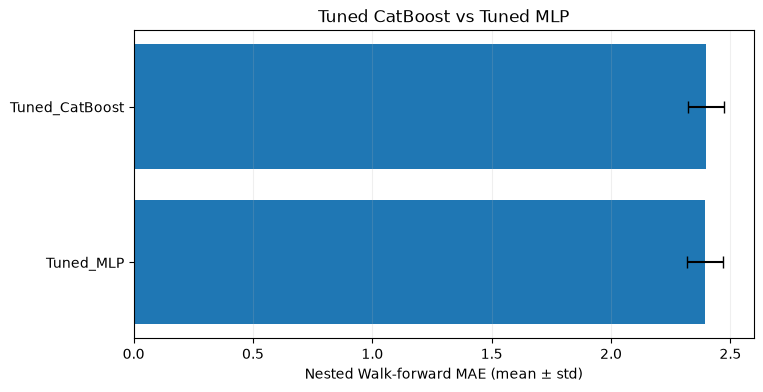

In [32]:
plot_df = tuned_summary.sort_values(
    "mae_mean",
    ascending=True
)

plt.figure(figsize=(8, 4))

plt.barh(
    plot_df["model"],
    plot_df["mae_mean"],
    xerr=plot_df["mae_std"],
    capsize=4,
)

plt.xlabel(
    "Nested Walk-forward MAE (mean ± std)"
)

plt.title(
    "Tuned CatBoost vs Tuned MLP"
)

plt.grid(
    axis="x",
    alpha=0.2,
)

plt.show()

## 29. Outer Validation Prediction 통합

후속 error/slice analysis에서 재사용합니다.

In [33]:
tuned_outer_predictions = pd.concat(
    [
        catboost_outer_predictions,
        mlp_outer_predictions,
    ],
    ignore_index=True,
)

print(
    "Prediction rows:",
    len(tuned_outer_predictions)
)

print(
    "Models:",
    tuned_outer_predictions["model"].unique()
)

tuned_outer_predictions.head()

Prediction rows: 6238
Models: <StringArray>
['Tuned_CatBoost', 'Tuned_MLP']
Length: 2, dtype: str


,player,team,league,season,target_season,position_group,goals,next_goals,fold,model,prediction
0,Aaron Ramsey,Juventus,Serie A,2020-2021,2021-2022,MF,2.0,0.0,1,Tuned_CatBoost,2.241380
1,Abdoulaye Doucouré,Everton,Premier League,2020-2021,2021-2022,MF,2.0,2.0,1,Tuned_CatBoost,2.207693
2,Abdoulaye Touré,Nantes,Ligue 1,2020-2021,2021-2022,MF,2.0,0.0,1,Tuned_CatBoost,1.392758
3,Adam Lallana,Brighton,Premier League,2020-2021,2021-2022,FW,1.0,0.0,1,Tuned_CatBoost,1.779061
4,Adam Ounas,Crotone,Serie A,2020-2021,2021-2022,FW,4.0,0.0,1,Tuned_CatBoost,3.676956


## 30. 결과 저장

In [34]:
ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTER_RESULT_PATH = (
    ARTIFACT_DIR
    / "07_tuned_outer_results.csv"
)

TUNED_SUMMARY_PATH = (
    ARTIFACT_DIR
    / "07_tuned_model_summary.csv"
)

CAT_TRIALS_PATH = (
    ARTIFACT_DIR
    / "07_catboost_optuna_trials.csv"
)

MLP_TRIALS_PATH = (
    ARTIFACT_DIR
    / "07_mlp_optuna_trials.csv"
)

PREDICTION_PATH = (
    ARTIFACT_DIR
    / "07_tuned_outer_predictions.csv"
)

CAT_PARAMS_PATH = (
    ARTIFACT_DIR
    / "07_catboost_best_params_by_fold.csv"
)

MLP_PARAMS_PATH = (
    ARTIFACT_DIR
    / "07_mlp_best_params_by_fold.csv"
)

tuned_outer_results.to_csv(
    OUTER_RESULT_PATH,
    index=False,
)

tuned_summary.to_csv(
    TUNED_SUMMARY_PATH,
    index=False,
)

catboost_trials.to_csv(
    CAT_TRIALS_PATH,
    index=False,
)

mlp_trials.to_csv(
    MLP_TRIALS_PATH,
    index=False,
)

tuned_outer_predictions.to_csv(
    PREDICTION_PATH,
    index=False,
)

catboost_params_df.to_csv(
    CAT_PARAMS_PATH,
    index=False,
)

mlp_params_df.to_csv(
    MLP_PARAMS_PATH,
    index=False,
)

print("Saved:")
for p in [
    OUTER_RESULT_PATH,
    TUNED_SUMMARY_PATH,
    CAT_TRIALS_PATH,
    MLP_TRIALS_PATH,
    PREDICTION_PATH,
    CAT_PARAMS_PATH,
    MLP_PARAMS_PATH,
]:
    print("-", p.resolve())

Saved:
- D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\07_tuned_outer_results.csv
- D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\07_tuned_model_summary.csv
- D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\07_catboost_optuna_trials.csv
- D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\07_mlp_optuna_trials.csv
- D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\07_tuned_outer_predictions.csv
- D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\07_catboost_best_params_by_fold.csv
- D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\07_mlp_best_params_by_fold.csv


## 31. 07 평가 프로토콜 저장

In [35]:
HPO_PROTOCOL = {
    "problem": (
        "conditional_next_big5_goals_regression"
    ),
    "feature_set": "Exp9Cb",
    "outer_validation_seasons": (
        OUTER_VAL_SEASONS
    ),
    "outer_scheme": "expanding_window",
    "hpo_scheme": (
        "nested walk-forward"
    ),
    "inner_folds_per_outer": (
        N_INNER_FOLDS
    ),
    "primary_metric": "MAE",
    "catboost_trials_per_outer": (
        N_TRIALS_CATBOOST
    ),
    "mlp_trials_per_outer": (
        N_TRIALS_MLP
    ),
    "test_input_season": (
        LOCKED_TEST_INPUT_SEASON
    ),
    "test_target_season": (
        LOCKED_TEST_TARGET_SEASON
    ),
    "test_status": (
        "LOCKED / NOT LOADED"
    ),
    "loss_experiment": (
        "NOT INCLUDED"
    ),
    "feature_reselection": (
        "NOT INCLUDED"
    ),
}

HPO_PROTOCOL

{'problem': 'conditional_next_big5_goals_regression',
 'feature_set': 'Exp9Cb',
 'outer_validation_seasons': ['2020-2021',
  '2021-2022',
  '2022-2023',
  '2023-2024'],
 'outer_scheme': 'expanding_window',
 'hpo_scheme': 'nested walk-forward',
 'inner_folds_per_outer': 3,
 'primary_metric': 'MAE',
 'catboost_trials_per_outer': 15,
 'mlp_trials_per_outer': 15,
 'test_input_season': '2024-2025',
 'test_target_season': '2025-2026',
 'test_status': 'LOCKED / NOT LOADED',
 'loss_experiment': 'NOT INCLUDED',
 'feature_reselection': 'NOT INCLUDED'}

# 32. 결과 해석 — 직접 작성

아래 결론은 **의도적으로 비워둡니다.**

## 확인할 질문

1. CatBoost는 tuning 후 실제 Outer MAE가 개선되었는가?
2. MLP는 tuning 후 실제 Outer MAE가 개선되었는가?
3. Inner MAE가 좋아졌는데 Outer MAE가 나빠진 Fold가 있는가?
4. HPO 자체가 과적합된 흔적은 없는가?
5. Tuned CatBoost와 Tuned MLP 중 평균 MAE 1위는 무엇인가?
6. MAE 표준편차가 가장 작은 모델은 무엇인가?
7. Worst Fold는 어느 모델이 더 안정적인가?
8. 10+/15+/20+ 고득점 MAE는 tuning으로 개선되었는가?
9. 고득점 bias는 여전히 강한 음수인가?
10. 전체 MAE 개선과 고득점자 개선이 같이 움직이는가?
11. CatBoost best params가 Outer Fold마다 크게 달라지는가?
12. MLP architecture/dropout/lr가 Fold마다 크게 달라지는가?
13. Trial 수를 더 늘릴 필요가 있는가?
14. 향후 최종 후보는 CatBoost / MLP 둘 다 유지할 것인가?

---

## 내 결론

- 전체 MAE 기준:
- 안정성 기준:
- 고득점자 기준:
- CatBoost tuning 효과:
- MLP tuning 효과:
- Hyperparameter 안정성:
- 추가 trial 필요 여부:
- 다음 단계에서 유지할 모델:
- 추가 확인이 필요한 점:

## 다음 단계

07 결과를 확인한 뒤 다음 작업으로 이동합니다.

현재 로드맵:

```text
08 이적 / 팀 변경 데이터 추가
09 Model A Big5 잔류 + Model B 득점
10 Feature / Embedding 재검증
11 Final Test + Slice/Error Analysis
12 재현 가능한 Pipeline
```

단, **Weighted Loss / Sample Weight는 모델 HPO와 다른 질문**이므로 필요하다면 별도의 목적함수 실험으로 분리합니다.

이번 07에서는 의도적으로 포함하지 않았습니다.